In [1]:
!git clone https://github.com/AGupta-23/RetinaScan

Cloning into 'RetinaScan'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 30 (delta 6), reused 28 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (30/30), 70.12 KiB | 14.02 MiB/s, done.
Resolving deltas: 100% (6/6), done.


label
0    1805
1    1857
Name: count, dtype: int64

No DR: 1805 (49.3%)
DR:    1857 (50.7%)


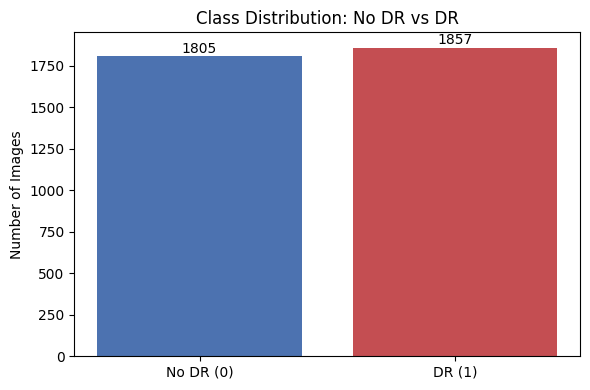

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the clean labels file you saved in Phase 3
df = pd.read_csv('/kaggle/working/RetinaScan/data/clean_labels.csv')  # adjust path if it's elsewhere

# Count classes
counts = df['label'].value_counts().sort_index()
print(counts)
print(f"\nNo DR: {counts[0]} ({counts[0]/len(df)*100:.1f}%)")
print(f"DR:    {counts[1]} ({counts[1]/len(df)*100:.1f}%)")

# Plot
plt.figure(figsize=(6, 4))
plt.bar(['No DR (0)', 'DR (1)'], counts.values, color=['#4C72B0', '#C44E52'])
plt.title('Class Distribution: No DR vs DR')
plt.ylabel('Number of Images')
for i, v in enumerate(counts.values):
    plt.text(i, v + 20, str(v), ha='center')
plt.tight_layout()
plt.savefig('/kaggle/working/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

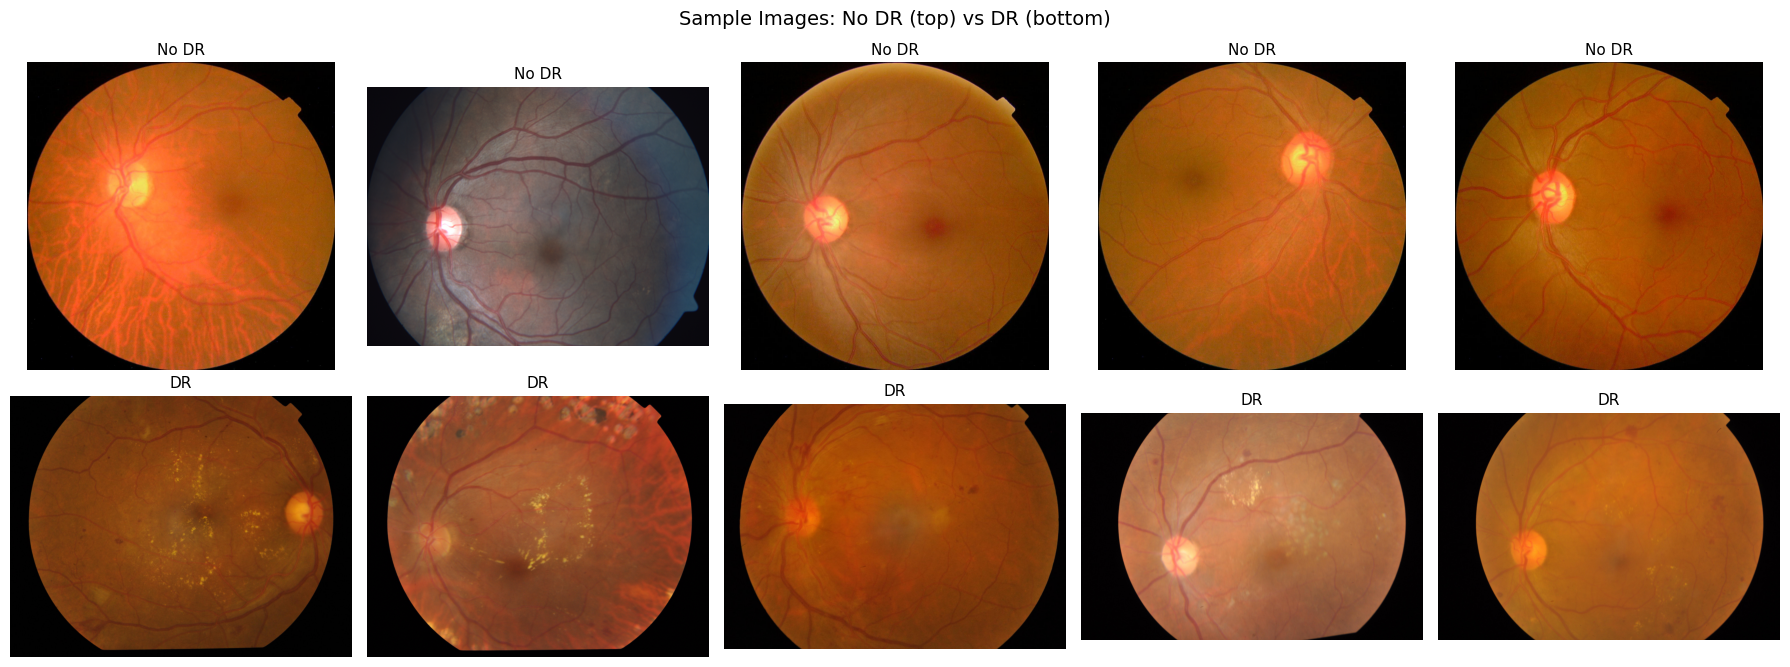

In [4]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

# Path to your training images (adjust to your actual Kaggle path)
IMG_DIR = '/kaggle/input/competitions/aptos2019-blindness-detection/train_images'

# Pick 5 random samples from each class
no_dr_samples = df[df['label'] == 0]['filename'].sample(5, random_state=42).tolist()
dr_samples = df[df['label'] == 1]['filename'].sample(5, random_state=42).tolist()

fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for i, fname in enumerate(no_dr_samples):
    img_path = os.path.join(IMG_DIR, fname)
    # Add .png extension if filenames don't already include it
    if not os.path.exists(img_path):
        img_path = img_path + '.png'
    img = Image.open(img_path)
    axes[0, i].imshow(img)
    axes[0, i].set_title('No DR', fontsize=11)
    axes[0, i].axis('off')

for i, fname in enumerate(dr_samples):
    img_path = os.path.join(IMG_DIR, fname)
    if not os.path.exists(img_path):
        img_path = img_path + '.png'
    img = Image.open(img_path)
    axes[1, i].imshow(img)
    axes[1, i].set_title('DR', fontsize=11)
    axes[1, i].axis('off')

plt.suptitle('Sample Images: No DR (top) vs DR (bottom)', fontsize=14)
plt.tight_layout()
plt.savefig('/kaggle/working/sample_images_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# adjust based on what you find above
import os
for root, dirs, files in os.walk('/kaggle/input/'):
    png_files = [f for f in files if f.endswith('.png')]
    if png_files:
        print(root, '→', len(png_files), 'png files, e.g.', png_files[0])

/kaggle/input/competitions/aptos2019-blindness-detection/train_images → 3662 png files, e.g. ef476be214d4.png
/kaggle/input/competitions/aptos2019-blindness-detection/test_images → 1928 png files, e.g. 755615db51d3.png


In [7]:
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

IMG_DIR = '/kaggle/input/competitions/aptos2019-blindness-detection/train_images/'

# For speed, sample a subset first (e.g. 500 images) rather than all 3662
# Once you trust it works, you can rerun on the full dataset
sample_df = df.sample(n=500, random_state=42).reset_index(drop=True)

records = []

for fname in tqdm(sample_df['filename']):
    img_path = os.path.join(IMG_DIR, fname)
    if not os.path.exists(img_path):
        img_path = img_path + '.png'

    img = cv2.imread(img_path)  # BGR by default
    if img is None:
        records.append({'filename': fname, 'width': None, 'height': None,
                         'channels': None, 'brightness': None, 'blur_score': None,
                         'readable': False})
        continue

    h, w, c = img.shape
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    brightness = gray.mean()
    blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()

    records.append({
        'filename': fname,
        'width': w,
        'height': h,
        'channels': c,
        'brightness': brightness,
        'blur_score': blur_score,
        'readable': True
    })

quality_df = pd.DataFrame(records)
quality_df.to_csv('/kaggle/working/image_quality_report.csv', index=False)

# Summary stats
print(quality_df[['width', 'height', 'brightness', 'blur_score']].describe())
print(f"\nUnreadable images: {(~quality_df['readable']).sum()}")

# Flag likely problem images
dark_threshold = quality_df['brightness'].quantile(0.05)   # bottom 5%
blur_threshold = quality_df['blur_score'].quantile(0.05)   # bottom 5%

dark_images = quality_df[quality_df['brightness'] <= dark_threshold]
blurry_images = quality_df[quality_df['blur_score'] <= blur_threshold]

print(f"\nPotentially dark/underexposed images: {len(dark_images)}")
print(f"Potentially blurry images: {len(blurry_images)}")

100%|██████████| 500/500 [01:04<00:00,  7.73it/s]


             width       height  brightness  blur_score
count   500.000000   500.000000  500.000000  500.000000
mean   2037.364000  1540.742000   68.030565   24.087087
std     917.732109   559.337243   17.119800   19.293211
min     474.000000   358.000000   19.249585    3.035914
25%    1050.000000  1050.000000   54.778249    9.419092
50%    2144.000000  1536.000000   69.467963   14.640670
75%    2588.000000  1958.000000   81.614409   43.299473
max    4288.000000  2848.000000  120.219333  121.919674

Unreadable images: 0

Potentially dark/underexposed images: 25
Potentially blurry images: 25


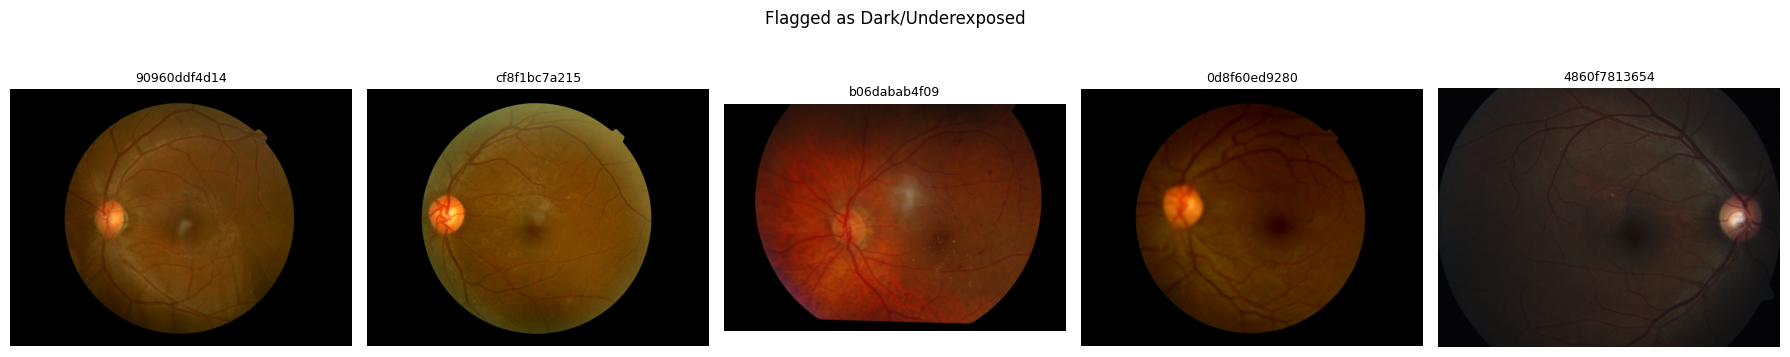

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, fname in enumerate(dark_images['filename'].head(5)):
    img_path = os.path.join(IMG_DIR, fname)
    if not os.path.exists(img_path):
        img_path = img_path + '.png'
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(f'{fname}', fontsize=9)
    axes[i].axis('off')
plt.suptitle('Flagged as Dark/Underexposed')
plt.tight_layout()
plt.savefig('/kaggle/working/flagged_dark_images.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
import os
for f in os.listdir('/kaggle/working/'):
    print(f)

class_distribution.png
RetinaScan
.virtual_documents
sample_images_by_class.png
flagged_dark_images.png
image_quality_report.csv


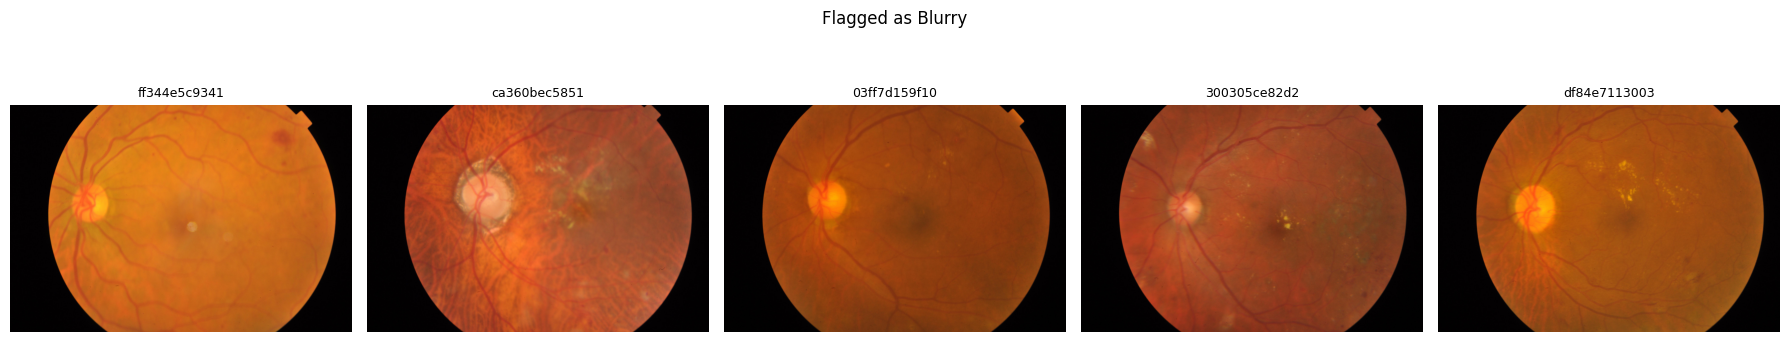

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, fname in enumerate(blurry_images['filename'].head(5)):
    img_path = os.path.join(IMG_DIR, fname)
    if not os.path.exists(img_path):
        img_path = img_path + '.png'
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(f'{fname}', fontsize=9)
    axes[i].axis('off')
plt.suptitle('Flagged as Blurry')
plt.tight_layout()
plt.savefig('/kaggle/working/flagged_blurry_images.png', dpi=150, bbox_inches='tight')
plt.show()